In [1]:
%pip install pyNetLogo

  Using cached pynetlogo-0.5.2-py3-none-any.whl.metadata (4.9 kB)
Using cached pynetlogo-0.5.2-py3-none-any.whl (25 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import itertools
import pynetlogo
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t


In [ ]:
import os
# os.environ['JAVA_HOME'] = r'C:\Program Files\Java\jdk-24'

In [ ]:
# Launch NetLogo (change the path to match your version)
# netlogo = pynetlogo.NetLogoLink(gui=False, netlogo_home='C:/Program Files/NetLogo 6.4.0')
netlogo = pynetlogo.NetLogoLink(gui=False, netlogo_home="/Users/yitong/Desktop/NetLogo Apps/NetLogo 6.4.0")

# Load your model
netlogo.load_model('Zoning v5.nlogo')
# netlogo.load_model('Future file.nlogo')

In [30]:
# Step 3: Parameter sweep and replications
lambda_values = [0.01, 0.02, 0.05, 0.1, 0.2,0.3, 0.4, 0.5, 1.0]
n_runs = 100

raw_results = []
summary_data = []

In [ ]:
for lam in lambda_values:
    run_outputs = []
    print(f"\nRunning {n_runs} simulations for lambda = {lam}")

    for run in range(n_runs):
        netlogo.command(f'set lambda {lam}')
        netlogo.command('setup')
        netlogo.command('go')

        # collect simulation output
        avg_transport = netlogo.report('average-transport-time')
        raw_results.append({
            'lambda': lam,
            'run': run + 1,
            'average_transport_time': avg_transport
        })
        # Stores the result in a list to calculate statistics
        run_outputs.append(avg_transport)
    
    # Compute statistics
    mean_val = np.mean(run_outputs)
    std_dev = np.std(run_outputs, ddof=1)
    conf_int = t.interval(0.95, df=n_runs-1, loc=mean_val, scale=std_dev / np.sqrt(n_runs))

    # one dictionary of statistics per lambda
    summary_data.append({
        'lambda': lam,
        'mean': mean_val,
        'ci_lower': conf_int[0],
        'ci_upper': conf_int[1]
    })




Running 100 simulations for lambda = 0.01

Running 100 simulations for lambda = 0.02

Running 100 simulations for lambda = 0.05

Running 100 simulations for lambda = 0.1

Running 100 simulations for lambda = 0.2

Running 100 simulations for lambda = 0.3

Running 100 simulations for lambda = 0.4

Running 100 simulations for lambda = 0.5

Running 100 simulations for lambda = 1.0


In [ ]:
# Step 4: Save to DataFrame
raw_df = pd.DataFrame(raw_results)
summary_df = pd.DataFrame(summary_data)

# raw results of each run
raw_df.to_csv('raw_lambda_results.csv', index=False)
# statistical summary of each lambda
summary_df.to_csv('summary_lambda_results.csv', index=False)



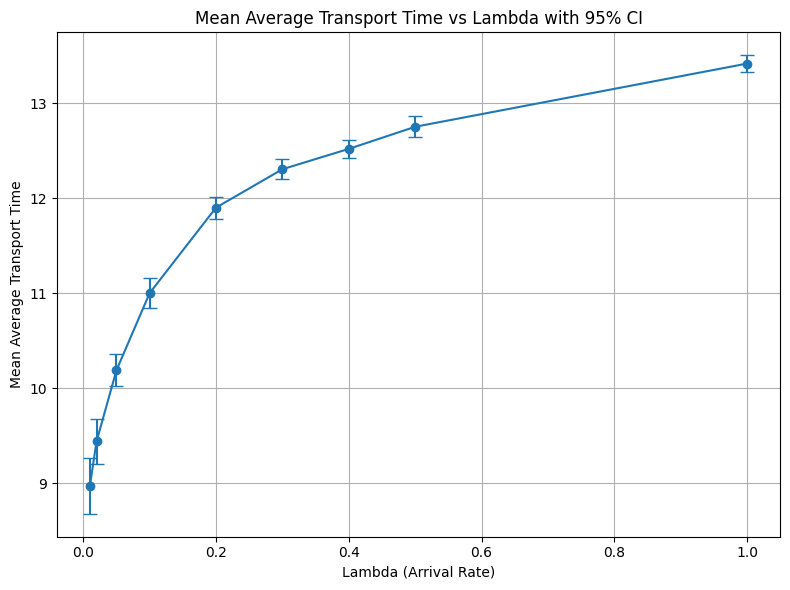

In [33]:
plt.figure(figsize=(8, 6))
plt.errorbar(summary_df['lambda'], summary_df['mean'],
             yerr=[summary_df['mean'] - summary_df['ci_lower'], summary_df['ci_upper'] - summary_df['mean']],
             fmt='-o', capsize=5)
plt.xlabel('Lambda (Arrival Rate)')
plt.ylabel('Mean Average Transport Time')
plt.title('Mean Average Transport Time vs Lambda with 95% CI')
plt.grid(True)
plt.tight_layout()
plt.show()